###  Importation of Libraries

In [114]:
import warnings
warnings.filterwarnings('ignore')

# Core data
import csv
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# NLP
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# ML — preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# ML — models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier

# ML — evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, classification_report)

# Clustering (NLP)
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# Explainability
import shap

# Persistence
import joblib
import os

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [115]:
#Global configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot style
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
})
PALETTE = ['#378ADD', '#D85A30', '#1D9E75', '#EF9F27', '#7F77DD', '#D4537E']

# File paths
PATH_DROPOUT   = '../data/data.csv'
PATH_ACADEMIC  = '../data/Academic Risk Prediction DW.csv'
PATH_EMPLOY    = '../data/UECD_1200_dataset.csv'
PATH_RESUME    = '../data/Resume text.csv.gz'

# Output directories
os.makedirs('models',  exist_ok=True)
os.makedirs('outputs', exist_ok=True)

print("✓ Configuration set — random seed:", RANDOM_SEED)

✓ Configuration set — random seed: 42


In [116]:
# Download NLTK data (run once)
for pkg in ['stopwords', 'wordnet', 'omw-1.4', 'punkt']:
    nltk.download(pkg, quiet=True)
print("✓ NLTK resources ready")


✓ NLTK resources ready


## DATA LOADING

In [117]:
# Loading the clean datasets from our Intro and Cleaning Notebook
df_dropout = pd.read_csv("../data/df_dropout_cleaned.csv")
df_academic = pd.read_csv("../data/df_academic_cleaned.csv")
df_employ = pd.read_csv("../data/df_employ_cleaned.csv")
df_resume = pd.read_csv("../data/df_resume_cleaned.csv")


# 6. Explanatory Data Analysis(EDA)

## 6.0 Summary

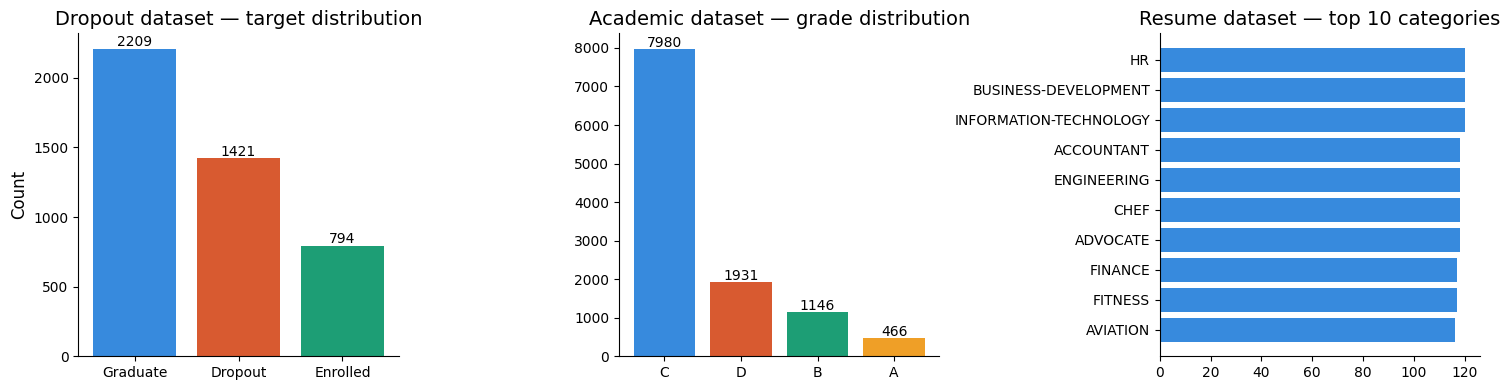

Chart saved → outputs/01_class_distributions.png


In [118]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Dropout target
counts = df_dropout['target'].value_counts()
axes[0].bar(counts.index, counts.values, color=PALETTE[:3])
axes[0].set_title('Dropout dataset — target distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

# Academic grade letters
counts2 = df_academic['grade_letter'].value_counts()
axes[1].bar(counts2.index, counts2.values, color=PALETTE[:4])
axes[1].set_title('Academic dataset — grade distribution')
for i, v in enumerate(counts2.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=10)

# Resume categories (top 10)
counts3 = df_resume['category'].value_counts().head(10)
axes[2].barh(counts3.index, counts3.values, color=PALETTE[0])
axes[2].set_title('Resume dataset — top 10 categories')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/01_class_distributions.png', bbox_inches='tight')
plt.show()
print("Chart saved → outputs/01_class_distributions.png")

## 6.1 EDA for Dropout Dataset

### 6.1.1 Distribution of student outcome

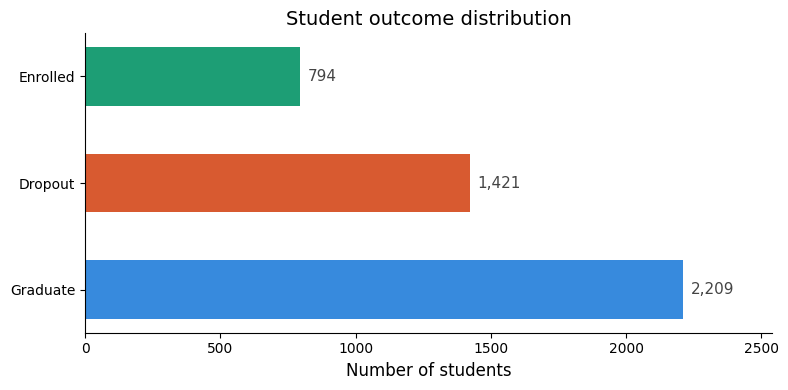

In [119]:
target_counts = df_dropout['target'].value_counts()
 
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    target_counts.index,
    target_counts.values,
    color=['#378ADD', '#D85A30', '#1D9E75'],
    height=0.55,
    edgecolor='none'
)
 
for bar, val in zip(bars, target_counts.values):
    ax.text(val + 30, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=11, color='#444')
 
ax.set_xlabel('Number of students')
ax.set_title('Student outcome distribution')
ax.set_xlim(0, target_counts.max() * 1.15)
plt.tight_layout()
plt.savefig('outputs/chart1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
 

### 6.1.2 Age at enrolment


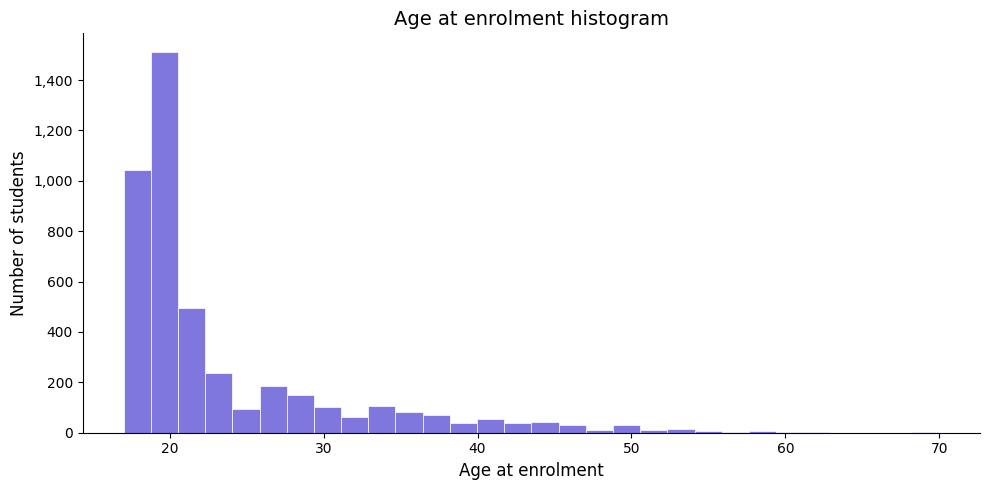

In [120]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    df_dropout['age_at_enrollment'],
    bins=30,
    color='#7F77DD',
    edgecolor='white',
    linewidth=0.5
)
ax.set_xlabel('Age at enrolment')
ax.set_ylabel('Number of students')
ax.set_title('Age at enrolment histogram')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('outputs/chart2_age_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.1.3 1st-semester grades by outcome

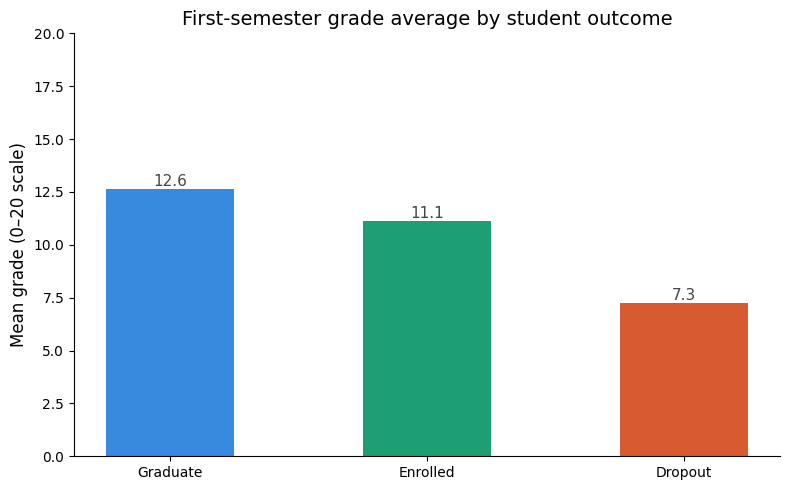

In [121]:
grade_col = 'curricular_units_1st_sem_grade'   # adjust if your column name differs
grade_means = df_dropout.groupby('target')[grade_col].mean().sort_values(ascending=False)
 
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'Graduate': '#378ADD', 'Dropout': '#D85A30', 'Enrolled': '#1D9E75'}
bar_colors = [colors.get(t, '#888') for t in grade_means.index]
 
bars = ax.bar(grade_means.index, grade_means.values, color=bar_colors,
              width=0.5, edgecolor='none')
 
for bar, val in zip(bars, grade_means.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.15,
            f'{val:.1f}', ha='center', fontsize=11, color='#444')
 
ax.set_ylim(0, 20)
ax.set_ylabel('Mean grade (0–20 scale)')
ax.set_title('First-semester grade average by student outcome')
plt.tight_layout()
plt.savefig('outputs/chart3_grade_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()
 

- This is arguably the single most important early-warning feature. Dropouts average a full 3.4 grade points lower than graduates in their very first semester — meaning the model can flag at-risk students as early as Week 14 of Year 1.

### 6.1.4 Financial Factors

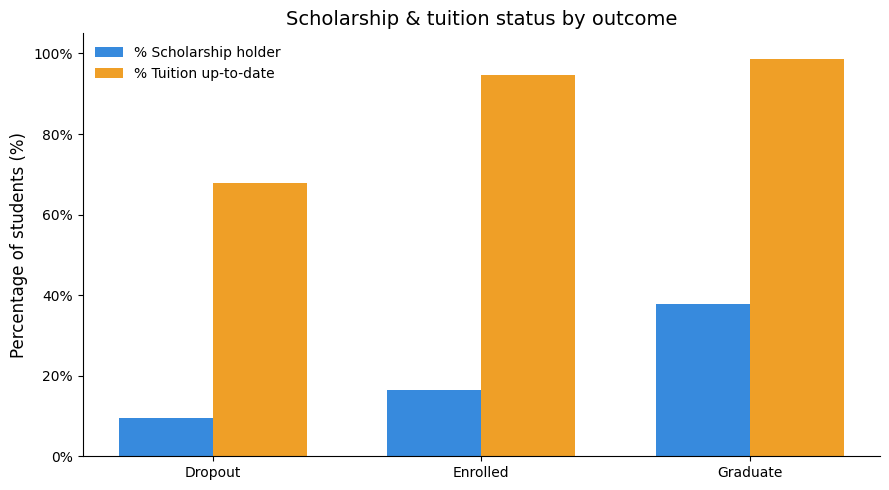

In [122]:
fin = df_dropout.groupby('target').agg(
    scholarship_pct=('scholarship_holder', 'mean'),
    tuition_pct=('tuition_fees_up_to_date', 'mean')
).reset_index()
fin['scholarship_pct'] *= 100
fin['tuition_pct'] *= 100
 
x = np.arange(len(fin))
width = 0.35
 
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, fin['scholarship_pct'], width, label='% Scholarship holder',
       color='#378ADD', edgecolor='none')
ax.bar(x + width / 2, fin['tuition_pct'], width, label='% Tuition up-to-date',
       color='#EF9F27', edgecolor='none')
 
ax.set_xticks(x)
ax.set_xticklabels(fin['target'])
ax.set_ylabel('Percentage of students (%)')
ax.set_title('Scholarship & tuition status by outcome')
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig('outputs/chart4_financial_factors.png', dpi=150, bbox_inches='tight')
plt.show()

- Students with scholarships graduate at nearly double the rate of those without. Similarly, students who are up-to-date on tuition payments graduate at ~82% vs ~35% for dropouts.

### 6.1.5 Outcome by debt status

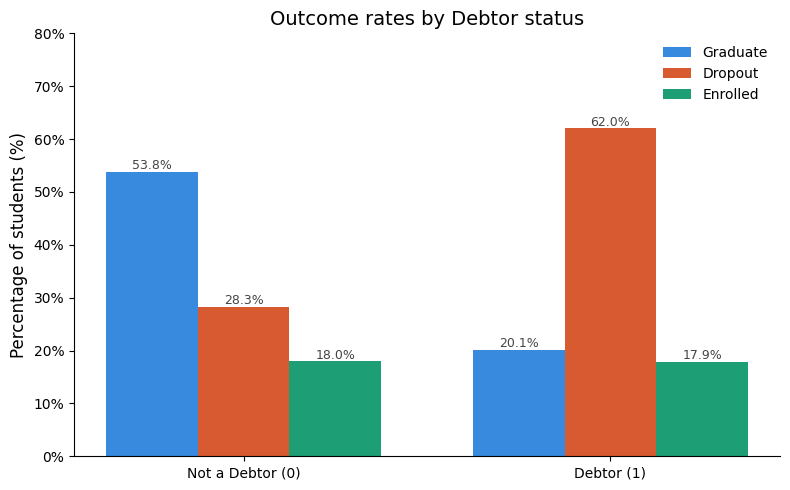

In [123]:

outcomes = ['Graduate', 'Dropout', 'Enrolled']
colors   = ['#378ADD', '#D85A30', '#1D9E75']
width    = 0.25

debtor_pct = (
    df_dropout.groupby('debtor')['target']
    .value_counts(normalize=True)
    .mul(100)
    .unstack(fill_value=0)
    .reindex(columns=outcomes, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(debtor_pct))

for i, (outcome, color) in enumerate(zip(outcomes, colors)):
    bars = ax.bar(x + i * width, debtor_pct[outcome], width,
                  label=outcome, color=color, edgecolor='none')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9, color='#444')

ax.set_xticks(x + width)
ax.set_xticklabels(['Not a Debtor (0)', 'Debtor (1)'])
ax.set_ylabel('Percentage of students (%)')
ax.set_title('Outcome rates by Debtor status')
ax.set_ylim(0, 80)
ax.legend(frameon=False, fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
plt.tight_layout()
plt.savefig('outputs/chartA_debtor_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.1.6 Outcome by Tuition fee status

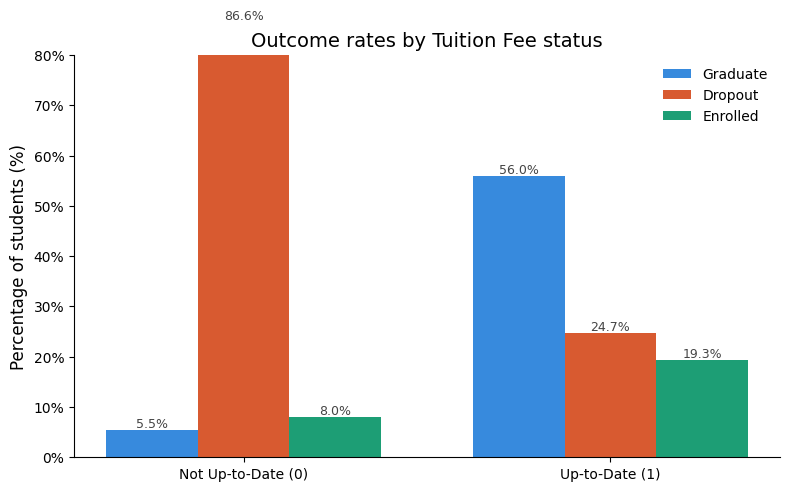

In [124]:
outcomes = ['Graduate', 'Dropout', 'Enrolled']
colors   = ['#378ADD', '#D85A30', '#1D9E75']
width    = 0.25

tuition_pct = (
    df_dropout.groupby('tuition_fees_up_to_date')['target']
    .value_counts(normalize=True)
    .mul(100)
    .unstack(fill_value=0)
    .reindex(columns=outcomes, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(tuition_pct))

for i, (outcome, color) in enumerate(zip(outcomes, colors)):
    bars = ax.bar(x + i * width, tuition_pct[outcome], width,
                  label=outcome, color=color, edgecolor='none')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9, color='#444')

ax.set_xticks(x + width)
ax.set_xticklabels(['Not Up-to-Date (0)', 'Up-to-Date (1)'])
ax.set_ylabel('Percentage of students (%)')
ax.set_title('Outcome rates by Tuition Fee status')
ax.set_ylim(0, 80)
ax.legend(frameon=False, fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
plt.tight_layout()
plt.savefig('outputs/chartB_tuition_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.1.7 Outcome by combined Debtor and Tuition status

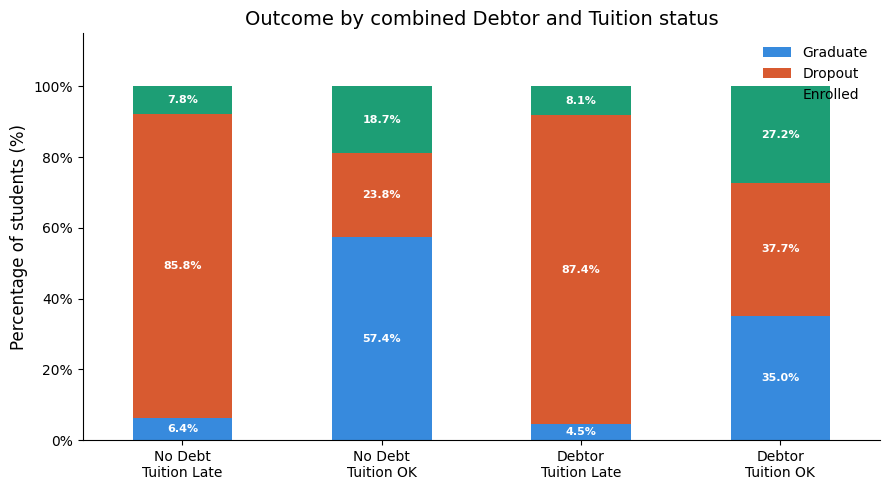

In [125]:
outcomes = ['Graduate', 'Dropout', 'Enrolled']
colors   = ['#378ADD', '#D85A30', '#1D9E75']

df_dropout['financial_group'] = (
    df_dropout['debtor'].astype(str) + '_' +
    df_dropout['tuition_fees_up_to_date'].astype(str)
)

group_labels = {
    '0_1': 'No Debt\nTuition OK',
    '0_0': 'No Debt\nTuition Late',
    '1_1': 'Debtor\nTuition OK',
    '1_0': 'Debtor\nTuition Late',
}

combo_pct = (
    df_dropout.groupby('financial_group')['target']
    .value_counts(normalize=True)
    .mul(100)
    .unstack(fill_value=0)
    .reindex(columns=outcomes, fill_value=0)
    .rename(index=group_labels)
)

fig, ax = plt.subplots(figsize=(9, 5))
combo_pct.plot(kind='bar', stacked=True, ax=ax,
               color=colors, edgecolor='none', width=0.5)

ax.set_title('Outcome by combined Debtor and Tuition status')
ax.set_ylabel('Percentage of students (%)')
ax.set_xlabel('')
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend(frameon=False, fontsize=10, loc='upper right')
plt.setp(ax.get_xticklabels(), rotation=0)

for bar_group in ax.containers:
    ax.bar_label(bar_group, fmt='%.1f%%', label_type='center',
                 fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/chartC_combined_financial.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.1.8 Dropout heatmap

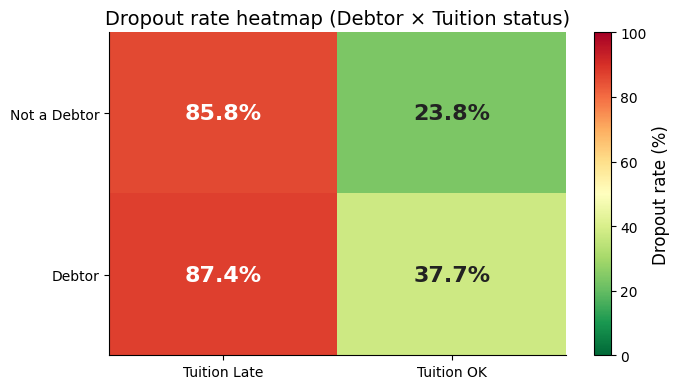

In [126]:
import matplotlib.pyplot as plt

heatmap_data = (
    df_dropout.groupby(['debtor', 'tuition_fees_up_to_date'])
    .apply(lambda g: (g['target'] == 'Dropout').mean() * 100)
    .unstack()
)
heatmap_data.index   = ['Not a Debtor', 'Debtor']
heatmap_data.columns = ['Tuition Late', 'Tuition OK']

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn_r',
               aspect='auto', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='Dropout rate (%)')

ax.set_xticks([0, 1])
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks([0, 1])
ax.set_yticklabels(heatmap_data.index)
ax.set_title('Dropout rate heatmap (Debtor × Tuition status)')

for i in range(2):
    for j in range(2):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=16, fontweight='bold',
                color='white' if val > 50 else '#222')

plt.tight_layout()
plt.savefig('outputs/chartD_dropout_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.1.9 Gender split by outcome

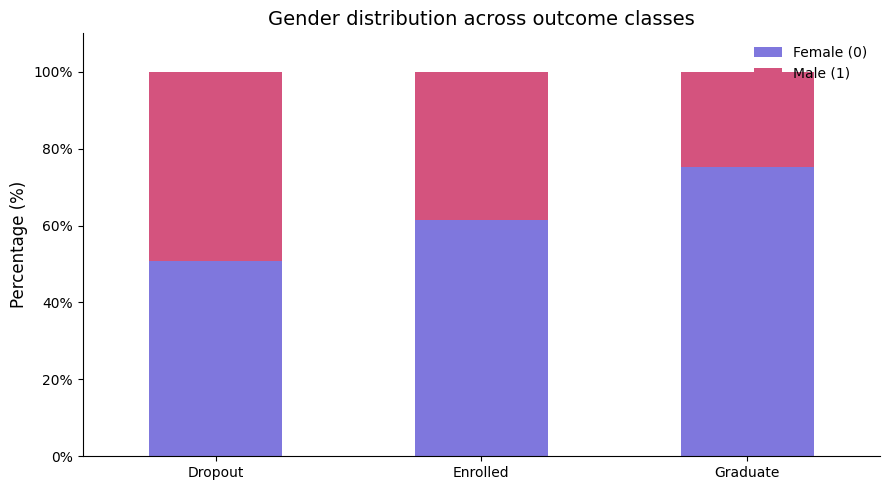

In [127]:
gender_counts = (
    df_dropout.groupby(['target', 'gender'])
    .size()
    .unstack(fill_value=0)
)
gender_pct = gender_counts.div(gender_counts.sum(axis=1), axis=0) * 100
 
fig, ax = plt.subplots(figsize=(9, 5))
gender_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#7F77DD', '#D4537E'],  # 0=Female purple, 1=Male pink
    edgecolor='none',
    width=0.5
)
ax.set_ylabel('Percentage (%)')
ax.set_title('Gender distribution across outcome classes')
ax.set_xlabel('')
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend(['Female (0)', 'Male (1)'], frameon=False, fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/chart5_gender_split.png', dpi=150, bbox_inches='tight')
plt.show()

- Male students make up a disproportionately large share of dropouts (~58%) relative to their total enrolment proportion. Female students show stronger graduation rates.

### 6.1.10 Curricular units approved

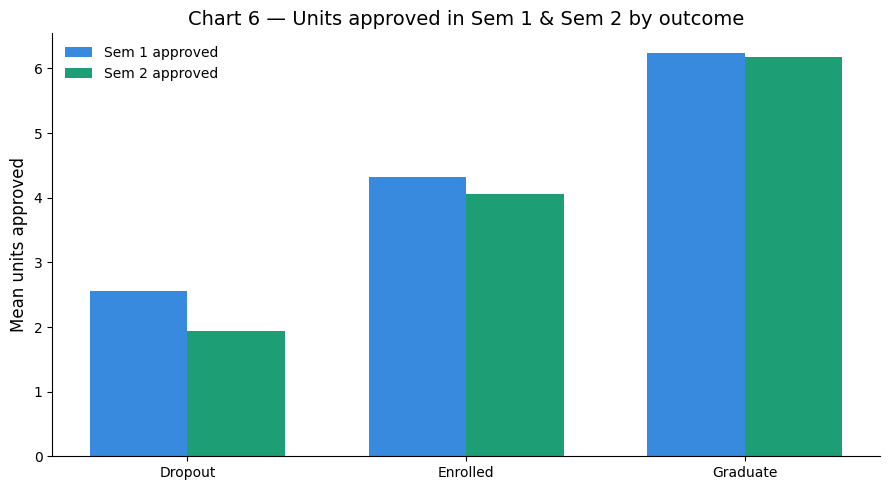

In [128]:
sem_cols = {
    'Sem 1 approved': 'curricular_units_1st_sem_approved',
    'Sem 2 approved': 'curricular_units_2nd_sem_approved',
}
sem_means = df_dropout.groupby('target')[[*sem_cols.values()]].mean()
 
x = np.arange(len(sem_means))
width = 0.35
 
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, sem_means.iloc[:, 0], width, label='Sem 1 approved',
       color='#378ADD', edgecolor='none')
ax.bar(x + width / 2, sem_means.iloc[:, 1], width, label='Sem 2 approved',
       color='#1D9E75', edgecolor='none')
 
ax.set_xticks(x)
ax.set_xticklabels(sem_means.index)
ax.set_ylabel('Mean units approved')
ax.set_title('Chart 6 — Units approved in Sem 1 & Sem 2 by outcome')
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig('outputs/chart6_units_approved.png', dpi=150, bbox_inches='tight')
plt.show()

- Graduates approve ~5.9 units per semester; dropouts approve fewer than 2. A student approving zero or one unit in Semester 1 is a very strong dropout signal and could directly trigger an advisor alert in your Streamlit interface.

### 6.1.11 Droupout correlation matrix

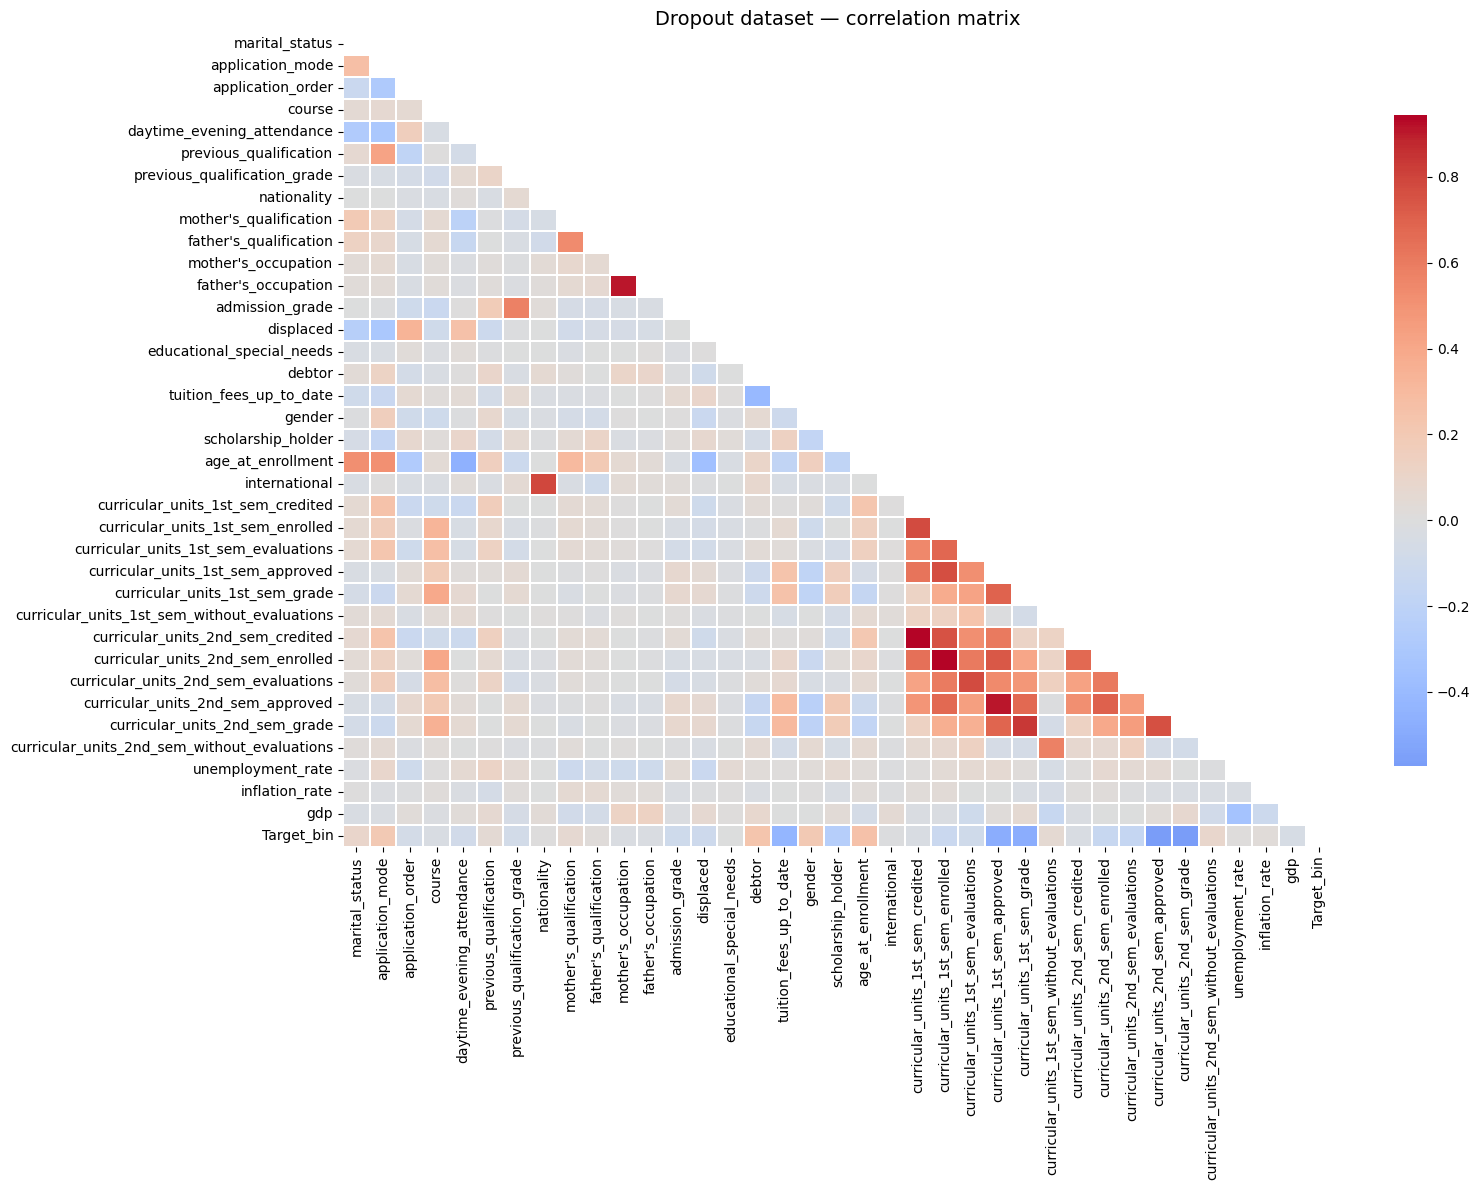

In [129]:
# Encode target temporarily for correlation
df_corr = df_dropout.copy()
df_corr['Target_bin'] = (df_corr['target'] == 'Dropout').astype(int)
numeric_cols = df_corr.select_dtypes(include=np.number).columns
corr = df_corr[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=False,
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Dropout dataset — correlation matrix', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/02_dropout_corr.png', bbox_inches='tight')
plt.show()

## 6.2 Academic

### 6.2.1 Grade Distribution

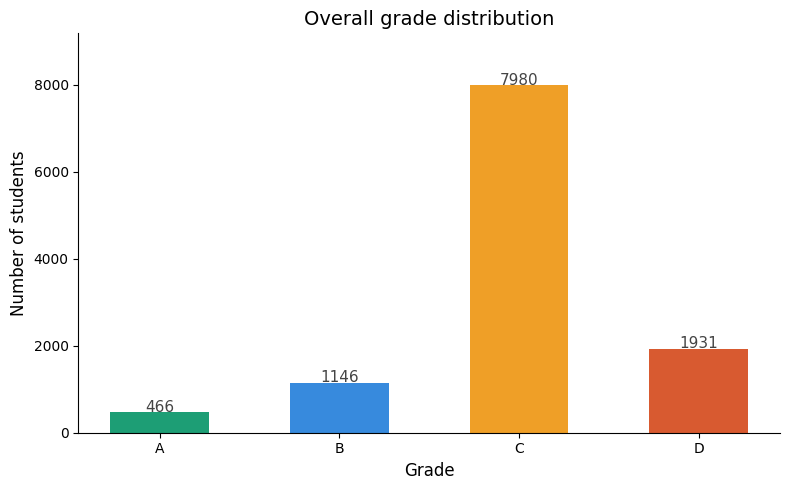

In [130]:
grade_order  = ['A', 'B', 'C', 'D']
colors_grade = ['#1D9E75', '#378ADD', '#EF9F27', '#D85A30', '#7F77DD']

counts = (
    df_academic['grade_letter']
    .value_counts()
    .reindex(grade_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values, color=colors_grade,
              width=0.55, edgecolor='none')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(val), ha='center', fontsize=11, color='#444')

ax.set_xlabel('Grade')
ax.set_ylabel('Number of students')
ax.set_title('Overall grade distribution')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig('outputs/academic_chart1_grade_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2.2 Grade Distribution by gender

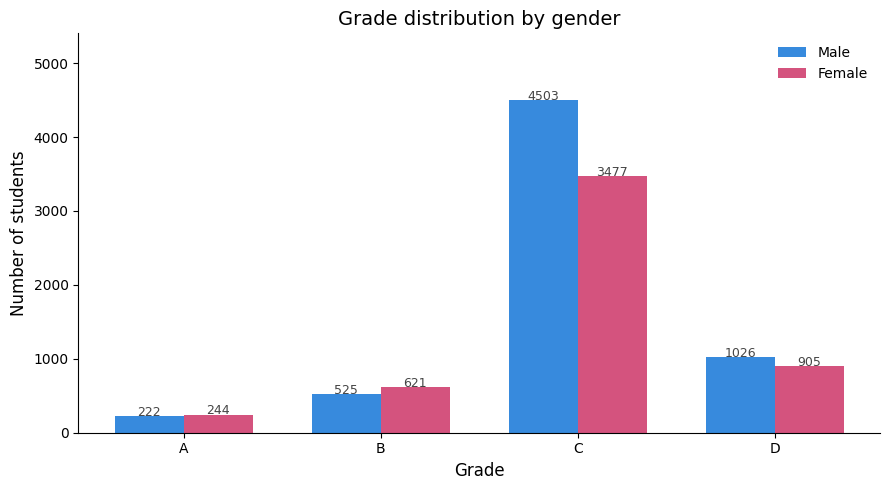

In [131]:
grade_order = ['A', 'B', 'C', 'D']

gender_grade = (
    df_academic.groupby(['gender', 'grade_letter'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=grade_order, fill_value=0)
)

x     = np.arange(len(grade_order))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars_m = ax.bar(x - width/2,
                gender_grade.loc['male']   if 'male'   in gender_grade.index else [0]*5,
                width, label='Male',   color='#378ADD', edgecolor='none')
bars_f = ax.bar(x + width/2,
                gender_grade.loc['female'] if 'female' in gender_grade.index else [0]*5,
                width, label='Female', color='#D4537E', edgecolor='none')

for bar in list(bars_m) + list(bars_f):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(bar.get_height())), ha='center', fontsize=9, color='#444')

ax.set_xticks(x)
ax.set_xticklabels(grade_order)
ax.set_xlabel('Grade')
ax.set_ylabel('Number of students')
ax.set_title('Grade distribution by gender')
ax.legend(frameon=False, fontsize=10)
ax.set_ylim(0, gender_grade.values.max() * 1.2)
plt.tight_layout()
plt.savefig('outputs/academic_chart2_grade_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2.3 Average exam score by topic and stage

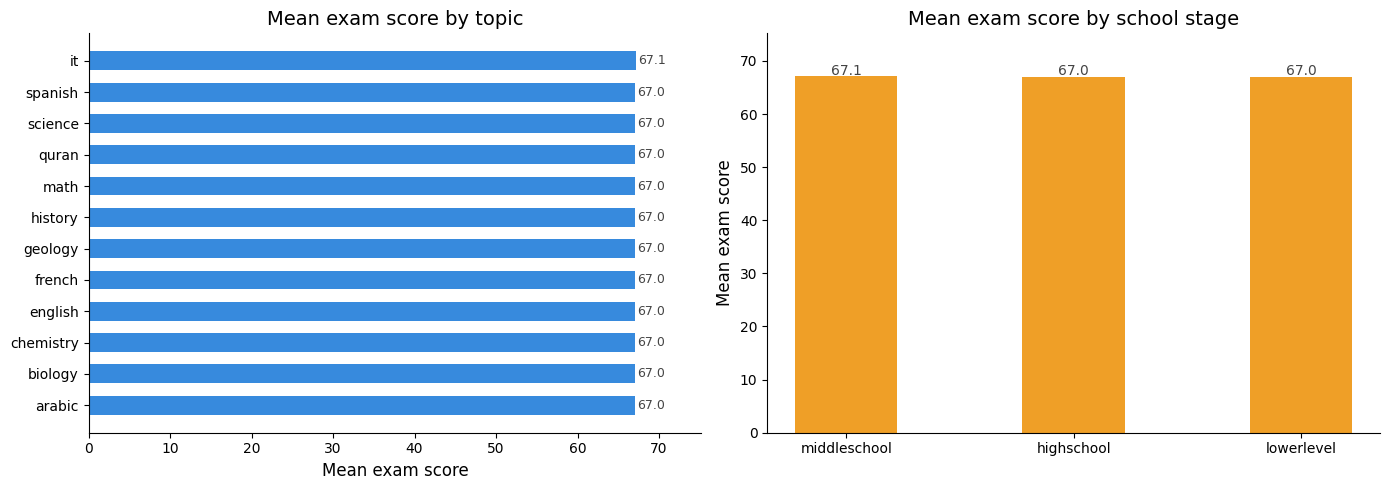

In [132]:
topic_scores = (
    df_academic.groupby('topic')['exam_score']
    .mean()
    .sort_values(ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — avg exam score by topic
axes[0].barh(topic_scores.index, topic_scores.values,
             color='#378ADD', height=0.6, edgecolor='none')
for i, val in enumerate(topic_scores.values):
    axes[0].text(val + 0.3, i, f'{val:.1f}', va='center',
                 fontsize=9, color='#444')
axes[0].set_xlabel('Mean exam score')
axes[0].set_title('Mean exam score by topic')
axes[0].set_xlim(0, topic_scores.max() * 1.12)

# Right — avg exam score by stage
stage_scores = (
    df_academic.groupby('stage')['exam_score']
    .mean()
    .sort_values(ascending=False)
)
axes[1].bar(stage_scores.index, stage_scores.values,
            color='#EF9F27', width=0.45, edgecolor='none')
for i, (stage, val) in enumerate(stage_scores.items()):
    axes[1].text(i, val + 0.3, f'{val:.1f}', ha='center',
                 fontsize=10, color='#444')
axes[1].set_ylabel('Mean exam score')
axes[1].set_title('Mean exam score by school stage')
axes[1].set_ylim(0, stage_scores.max() * 1.12)

plt.tight_layout()
plt.savefig('outputs/academic_chart3_score_by_topic_stage.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2.4 Study behaviour vs exam score

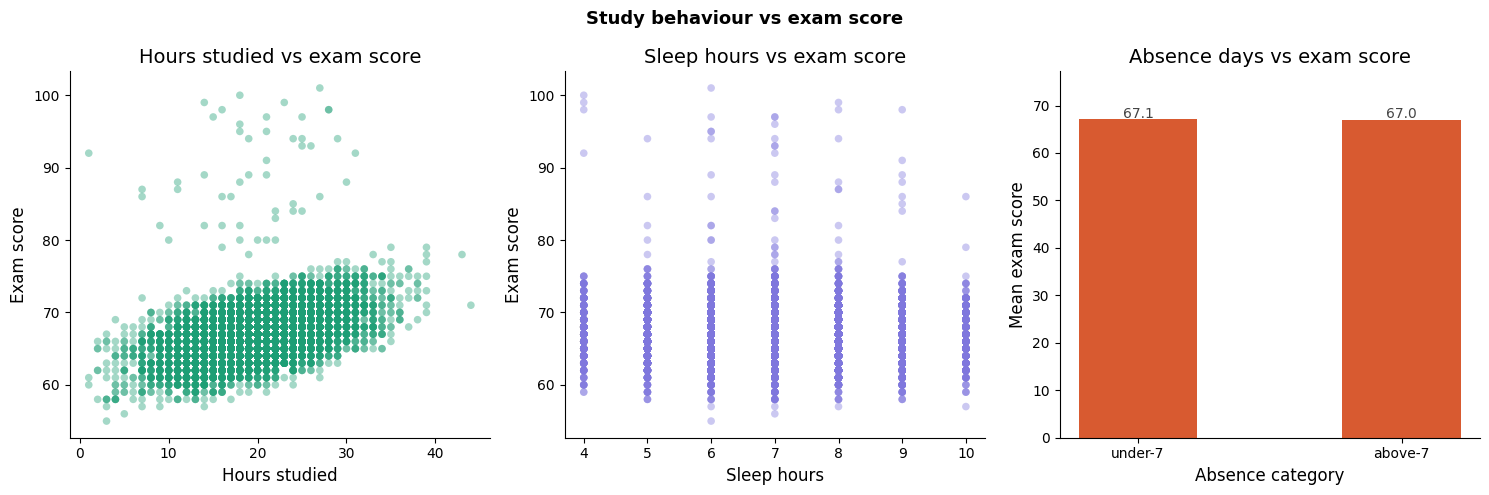

In [133]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Study behaviour vs exam score', fontsize=13, fontweight='bold')

# Left — hours studied vs exam score
axes[0].scatter(df_academic['hours_studied'], df_academic['exam_score'],
                alpha=0.4, color='#1D9E75', s=30, edgecolors='none')
axes[0].set_xlabel('Hours studied')
axes[0].set_ylabel('Exam score')
axes[0].set_title('Hours studied vs exam score')

# Centre — sleep hours vs exam score
axes[1].scatter(df_academic['sleep_hours'], df_academic['exam_score'],
                alpha=0.4, color='#7F77DD', s=30, edgecolors='none')
axes[1].set_xlabel('Sleep hours')
axes[1].set_ylabel('Exam score')
axes[1].set_title('Sleep hours vs exam score')

# Right — mean exam score by absence category
absence_score = (
    df_academic.groupby('absence_days')['exam_score']
    .mean()
    .sort_values(ascending=False)
)
axes[2].bar(absence_score.index, absence_score.values,
            color='#D85A30', width=0.45, edgecolor='none')
for i, val in enumerate(absence_score.values):
    axes[2].text(i, val + 0.3, f'{val:.1f}', ha='center',
                 fontsize=10, color='#444')
axes[2].set_xlabel('Absence category')
axes[2].set_ylabel('Mean exam score')
axes[2].set_title('Absence days vs exam score')
axes[2].set_ylim(0, absence_score.max() * 1.15)

plt.tight_layout()
plt.savefig('outputs/academic_chart4_behaviour_vs_score.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3 Employability

### 6.3.1 Competitiveness score distribution

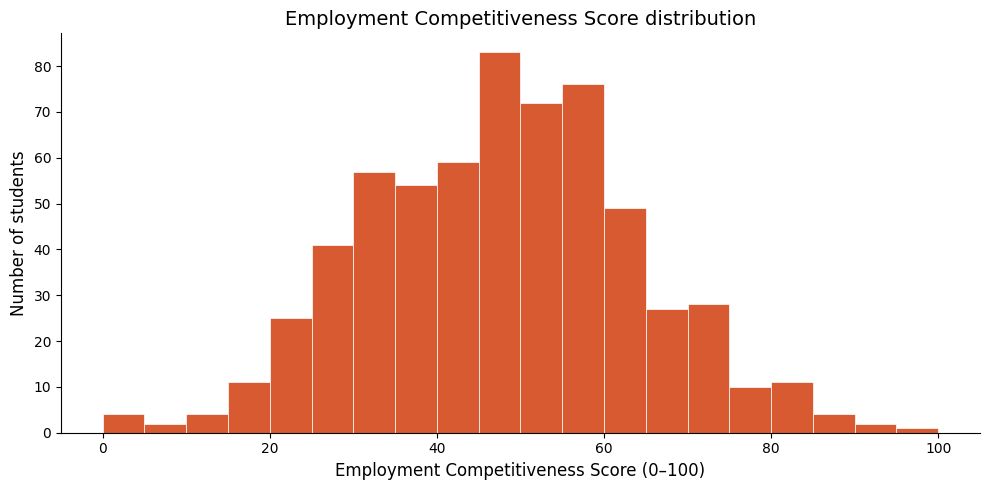

In [134]:
score_col = 'employment_competitiveness_score'
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    df_employ[score_col].dropna(),
    bins=20,
    color='#D85A30',
    edgecolor='white',
    linewidth=0.5
)
ax.set_xlabel('Employment Competitiveness Score (0–100)')
ax.set_ylabel('Number of students')
ax.set_title('Employment Competitiveness Score distribution')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('outputs/chart7_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3.2 GPA vs employability

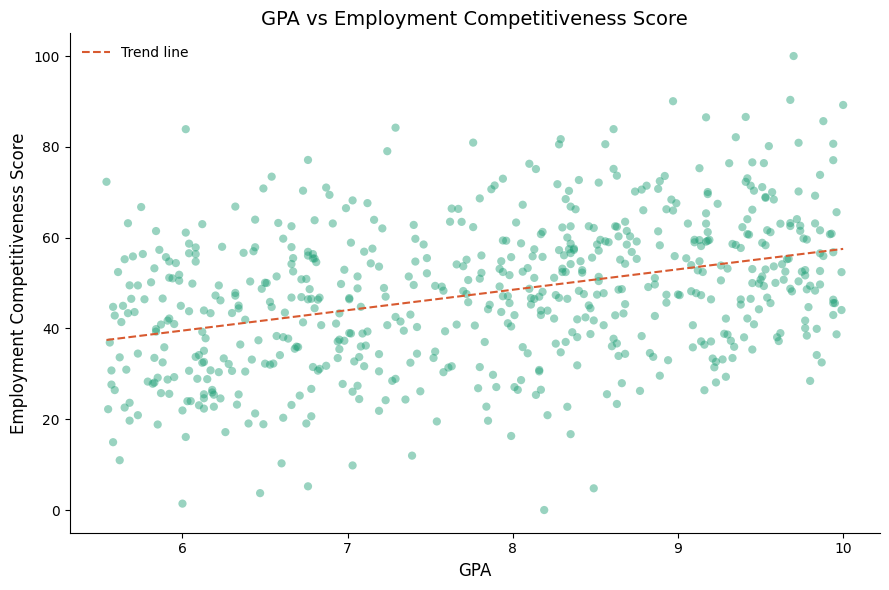

In [135]:
gpa_col   = 'gpa'                               # e.g. 'cgpa' or 'gpa'
score_col = 'employment_competitiveness_score'
 
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    df_employ[gpa_col],
    df_employ[score_col],
    alpha=0.45,
    color='#1D9E75',
    s=35,
    edgecolors='none'
)
 
# Optional: regression trend line
from numpy.polynomial.polynomial import polyfit
mask = df_employ[[gpa_col, score_col]].notna().all(axis=1)
x_vals = df_employ.loc[mask, gpa_col]
y_vals = df_employ.loc[mask, score_col]
b, m = polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(x_line, b + m * x_line, color='#D85A30', linewidth=1.5,
        linestyle='--', label='Trend line')
 
ax.set_xlabel('GPA')
ax.set_ylabel('Employment Competitiveness Score')
ax.set_title('GPA vs Employment Competitiveness Score')
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig('outputs/chart8_gpa_vs_score.png', dpi=150, bbox_inches='tight')
plt.show()

- There's a clear positive correlation, but the spread is large. A student with a 3.8 GPA can score anywhere from 50 to 95 — meaning factors like research participation, extracurriculars, and technical skills add significant independent explanatory power beyond grades alone.

### 6.3.3 Skill category scores

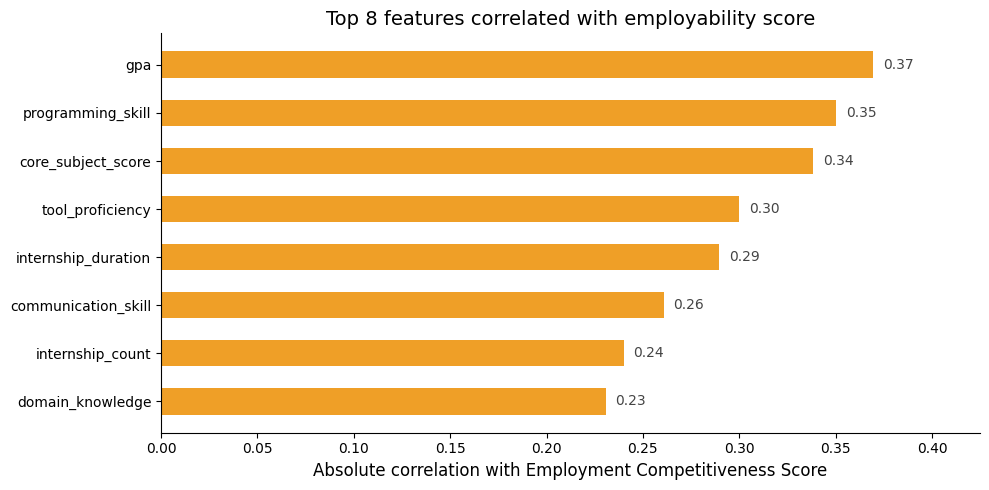

In [136]:
# CHART 9 — Top features correlated with Employment Competitiveness Score (df_employ)

score_col = 'employment_competitiveness_score'

# Compute correlation of every numeric feature with the target score
correlations = (
    df_employ
    .drop(columns=[score_col])
    .corrwith(df_employ[score_col])
    .dropna()
    .abs()
    .sort_values(ascending=True)
    .tail(8)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    correlations.index,
    correlations.values,
    color='#EF9F27',
    height=0.55,
    edgecolor='none'
)

for bar, val in zip(bars, correlations.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10, color='#444')

ax.set_xlabel('Absolute correlation with Employment Competitiveness Score')
ax.set_title('Top 8 features correlated with employability score')
ax.set_xlim(0, correlations.max() * 1.15)
plt.tight_layout()
plt.savefig('outputs/chart9_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3.4 Employability - skills vs competitive score

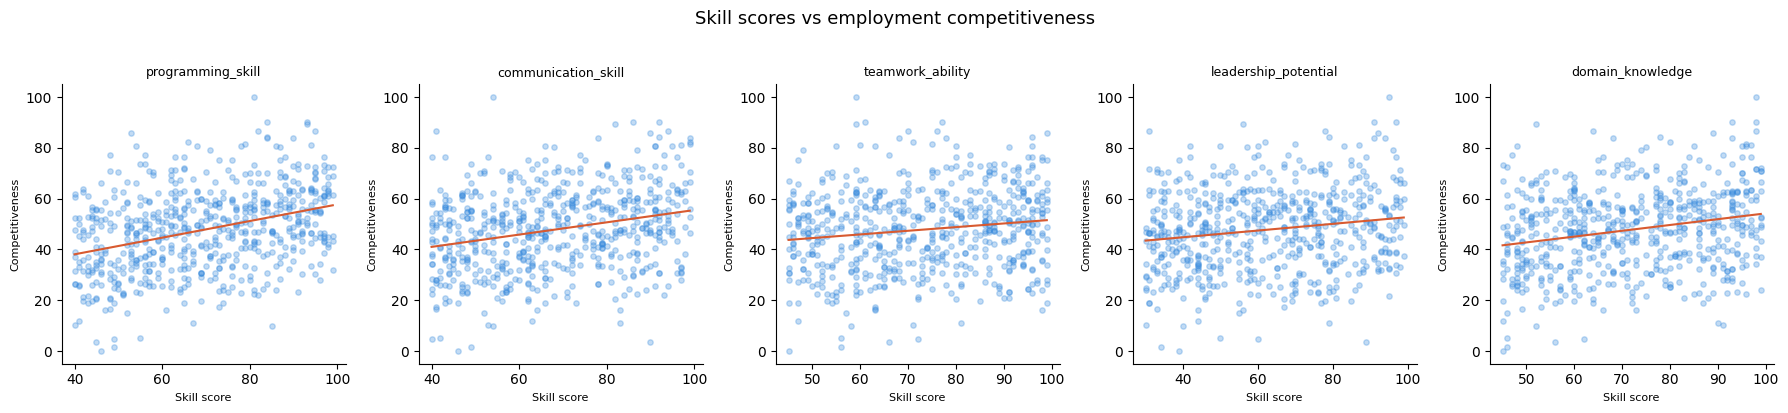

In [137]:

skill_cols = ['programming_skill','communication_skill','teamwork_ability',
              'leadership_potential','domain_knowledge']
df_emp_score = df_employ.dropna(subset=['employment_competitiveness_score'])

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, skill_cols):
    ax.scatter(df_emp_score[col], df_emp_score['employment_competitiveness_score'],
               alpha=0.3, s=15, color=PALETTE[0])
    # trend line
    m, b = np.polyfit(df_emp_score[col].dropna(),
                      df_emp_score.loc[df_emp_score[col].notna(),
                      'employment_competitiveness_score'], 1)
    xs = np.linspace(df_emp_score[col].min(), df_emp_score[col].max(), 100)
    ax.plot(xs, m*xs+b, color=PALETTE[1], linewidth=1.5)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Skill score', fontsize=8)
    ax.set_ylabel('Competitiveness', fontsize=8)

plt.suptitle('Skill scores vs employment competitiveness', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/02_skill_vs_employ.png', bbox_inches='tight')
plt.show()

## 6.3.5 Correlation heatmap — employability dataset 

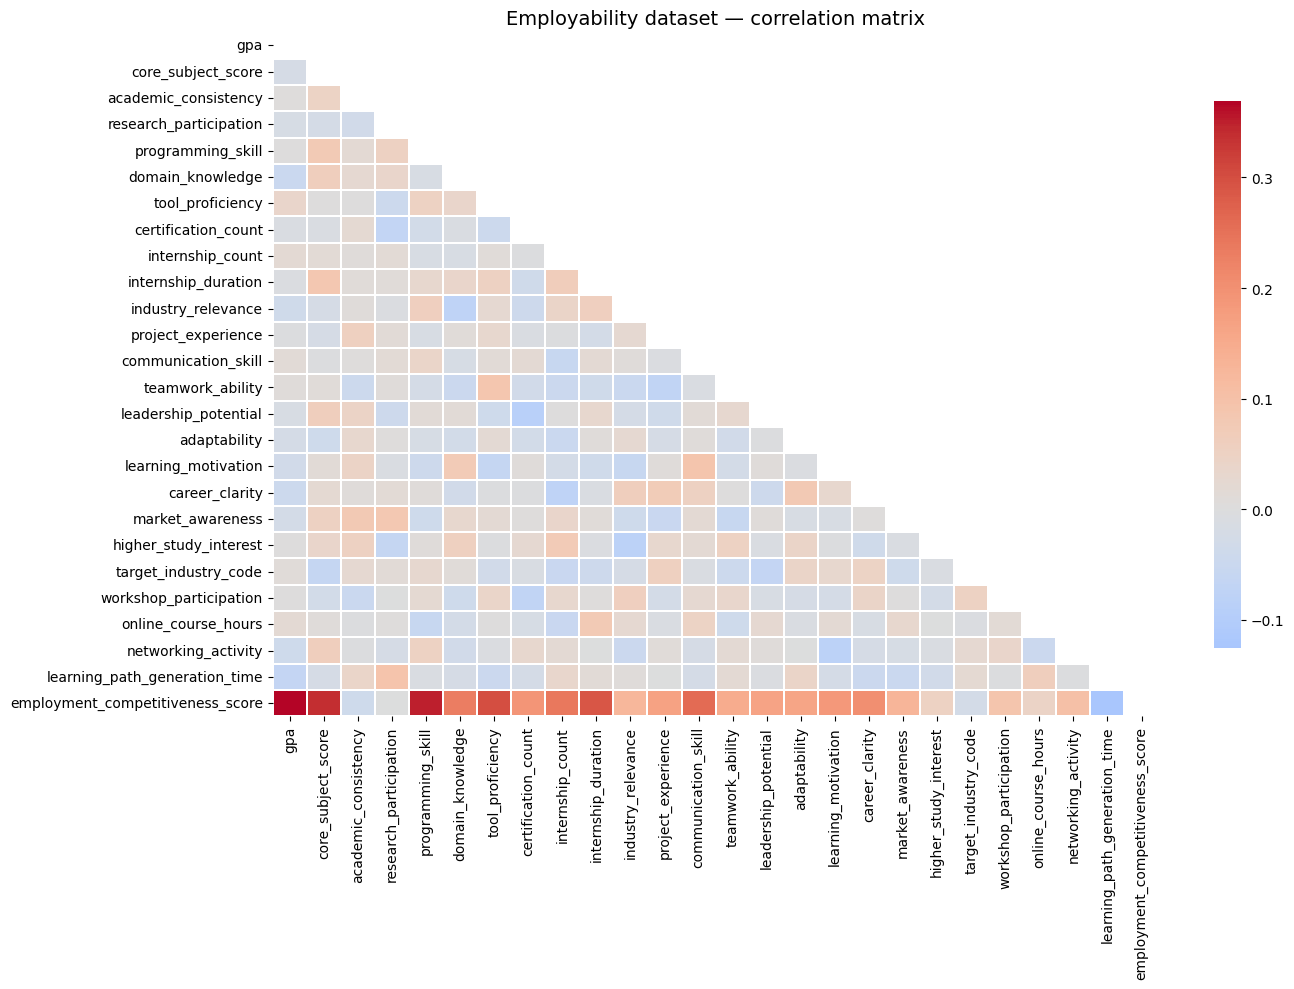

In [138]:

emp_num = df_employ.select_dtypes(include=np.number)
corr_e  = emp_num.corr()

mask = np.triu(np.ones_like(corr_e, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_e, mask=mask, cmap='coolwarm', center=0, annot=False,
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Employability dataset — correlation matrix', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/02_employ_corr.png', bbox_inches='tight')
plt.show()

## 6.4 Resume

### 6.4.1  Resume category imbalance

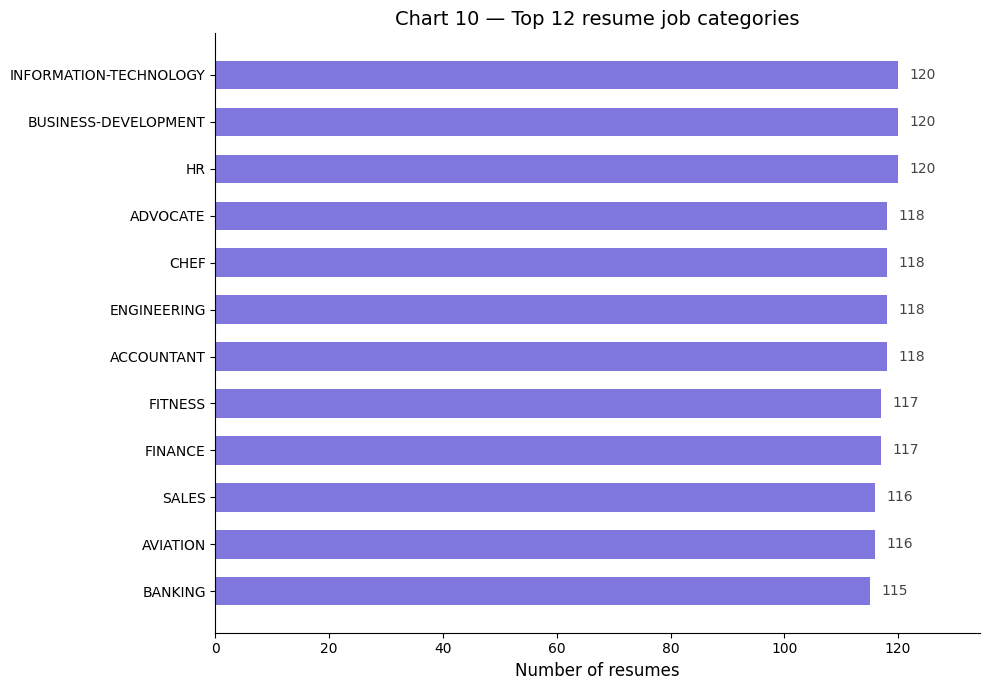

In [139]:
top_cats = (
    df_resume['category']
    .value_counts()
    .head(12)
    .sort_values(ascending=True)   # ascending so longest bar is at top
)
 
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top_cats.index,
    top_cats.values,
    color='#7F77DD',
    height=0.6,
    edgecolor='none'
)
 
for bar, val in zip(bars, top_cats.values):
    ax.text(val + 2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10, color='#444')
 
ax.set_xlabel('Number of resumes')
ax.set_title('Chart 10 — Top 12 resume job categories')
ax.set_xlim(0, top_cats.max() * 1.12)
plt.tight_layout()
plt.savefig('outputs/chart10_resume_categories.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.4.2 Most frequent keywords

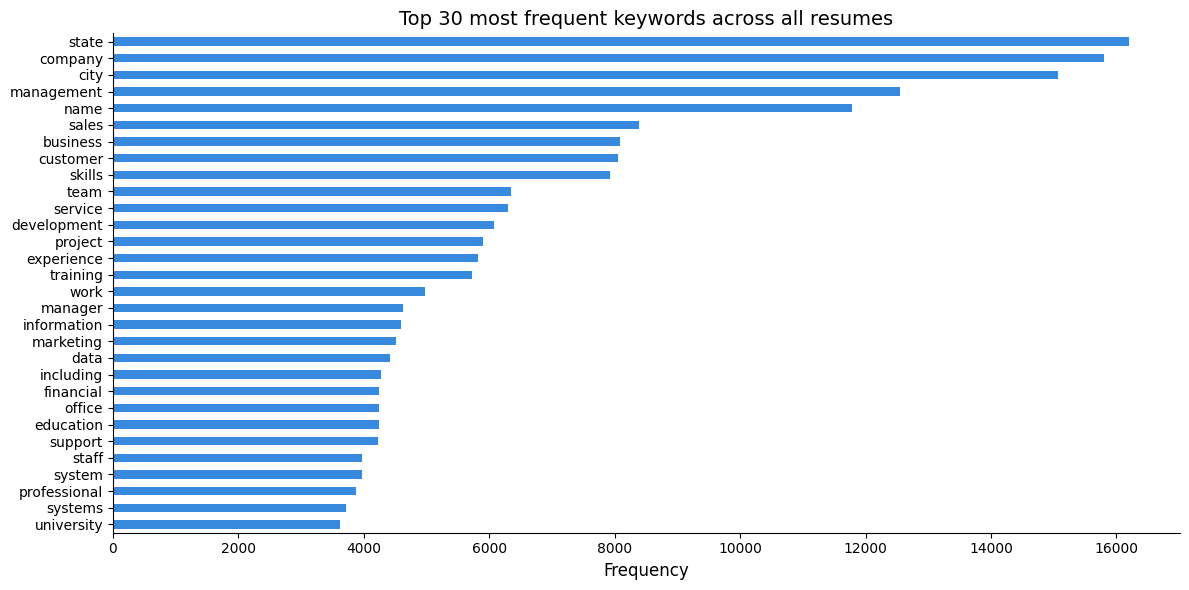

In [140]:

stop_words = set(stopwords.words('english'))
all_text = ' '.join(df_resume['resume_text'].dropna().astype(str))
tokens = [w for w in all_text.lower().split()
          if w.isalpha() and w not in stop_words and len(w) > 3]
freq = pd.Series(tokens).value_counts().head(30)

fig, ax = plt.subplots(figsize=(12, 6))
freq.sort_values().plot(kind='barh', ax=ax, color=PALETTE[0])
ax.set_title('Top 30 most frequent keywords across all resumes')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('outputs/02_resume_keyword_freq.png', bbox_inches='tight')
plt.show()

# 7. FEATURE ENGINEERING AND PREPROCESSING

## 7.1 Dropout Dataset

In [141]:

# FEATURE ENGINEERING

df_dropout['total_units_approved'] = df_dropout['curricular_units_1st_sem_approved'] + df_dropout['curricular_units_2nd_sem_approved']
df_dropout['grade_improvement'] = df_dropout['curricular_units_2nd_sem_grade'] - df_dropout['curricular_units_1st_sem_grade']
df_dropout['financial_pressure'] = ((df_dropout['debtor'] == 1) & (df_dropout['tuition_fees_up_to_date'] == 0)).astype(int)

# ONE HOT ENCODING
le_dropout = LabelEncoder()
df_dropout['target_encoded'] = le_dropout.fit_transform(df_dropout['target'])

# SCALING
scaler_dropout = StandardScaler()
cols_to_scale = ['age_at_enrollment', 'admission_grade', 'curricular_units_1st_sem_grade', 
                 'curricular_units_2nd_sem_grade', 'total_units_approved', 'grade_improvement']
df_dropout[cols_to_scale] = scaler_dropout.fit_transform(df_dropout[cols_to_scale])




 ### 7.1.1 Checking for Imbalance 

In [142]:
def plot_imbalance(before_series, after_series, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Before SMOTE
    sns.countplot(x=before_series, ax=axes[0], palette=PALETTE)
    axes[0].set_title(f'{title} - Before SMOTE')
    axes[0].set_ylabel('Number of Students')
    
    # After SMOTE
    sns.countplot(x=after_series, ax=axes[1], palette=PALETTE)
    axes[1].set_title(f'{title} - After SMOTE (Balanced)')
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()


target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64

✅ Dropout Balanced! All classes now have 2209 samples.


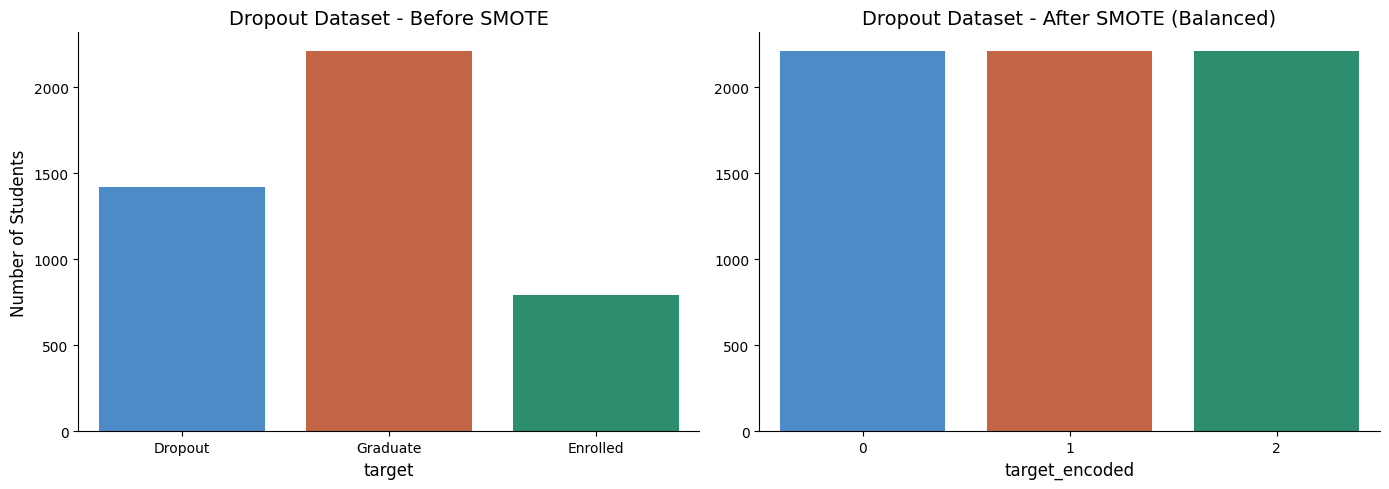

In [143]:
from imblearn.over_sampling import SMOTE

# Checking for Imbalance

print(df_dropout['target'].value_counts(normalize=True) * 100)



X_dropout = df_dropout[['age_at_enrollment', 'admission_grade', 'total_units_approved', 'scholarship_holder', 'debtor']]
y_dropout = df_dropout['target_encoded']

# Applying SMOTE
sm = SMOTE(random_state=42)
X_drop_res, y_drop_res = sm.fit_resample(X_dropout, y_dropout)

print(f"\n✅ Dropout Balanced! All classes now have {len(y_drop_res) // 3} samples.")

plot_imbalance(df_dropout['target'], y_drop_res, "Dropout Dataset")


#  CSV to be loaded in Modelling notebook
df_dropout_balanced = pd.concat([pd.DataFrame(X_drop_res), pd.Series(y_drop_res, name='target')], axis=1)
df_dropout_balanced.to_csv("../data/df_dropout_preprocessed.csv", index=1)


## 7.2 Academic Dataset

In [144]:
# CREATING TARGET VARIABLE AND FEATURE ENGINEERING
def categorize_status(row):
    if row['grade_letter'] in ['A', 'B']: return 'High Performance'
    elif row['grade_letter'] == 'C': return 'Average'
    else: return 'At Risk'

df_academic['academic_status'] = df_academic.apply(categorize_status, axis=1)
df_academic['engagement_score'] = df_academic[['raisedhands', 'visited_resources', 'announcements_view', 'discussion']].mean(axis=1)
df_academic['study_efficiency'] = df_academic['avg_score'] / (df_academic['hours_studied'] + 1)

# ENCODING
df_academic['academic_status_encoded'] = LabelEncoder().fit_transform(df_academic['academic_status'])
df_academic['gender_encoded'] = df_academic['gender'].map({'male': 1, 'female': 0})

# SCALING
scaler_academic = StandardScaler()
academic_scale_cols = ['gpa', 'absences', 'hours_studied', 'engagement_score', 'study_efficiency']
df_academic[academic_scale_cols] = scaler_academic.fit_transform(df_academic[academic_scale_cols])

df_academic.to_csv("../data/df_academic_preprocessed.csv", index=False)



### 7.2.1 Checking for Imbalance

academic_status
Average             69.252799
At Risk             16.757789
High Performance    13.989412
Name: proportion, dtype: float64


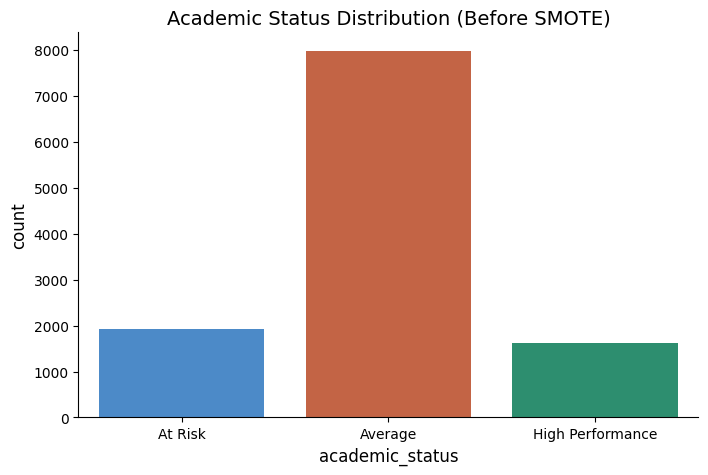


✅ Imbalance Fixed! All classes now have 7980 samples.


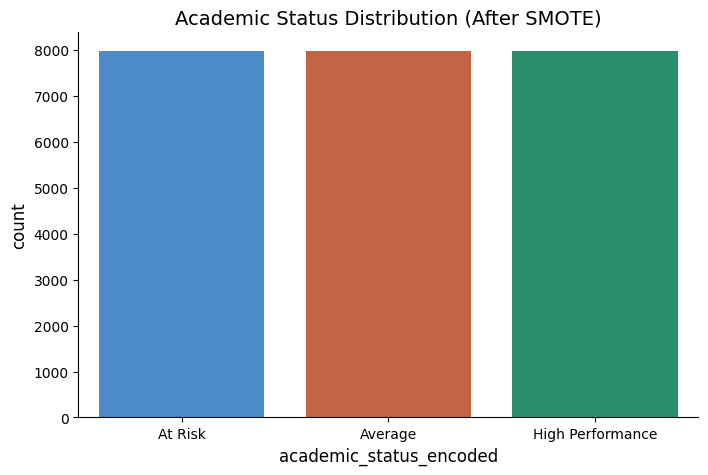

In [145]:
from imblearn.over_sampling import SMOTE
from collections import Counter

#  Academic Status Distribution (Before SMOTE)
print(df_academic['academic_status'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
sns.countplot(x='academic_status', data=df_academic, palette=PALETTE)
plt.title('Academic Status Distribution (Before SMOTE)')
plt.show()

# Prepare Features (X) and Target (y) for SMOTE

X_academic = df_academic[['gpa', 'absences', 'hours_studied', 'engagement_score', 'study_efficiency']]
y_academic = df_academic['academic_status_encoded']

# Applying SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_academic, y_academic)

print(f"\n✅ Imbalance Fixed! All classes now have {Counter(y_res)[0]} samples.")

# Visual
plt.figure(figsize=(8, 5))
sns.countplot(x=y_res, palette=PALETTE)
plt.title('Academic Status Distribution (After SMOTE)')
plt.xticks(ticks=[0, 1, 2], labels=['At Risk', 'Average', 'High Performance']) # Labels depend on your LabelEncoder mapping
plt.show()

# 5. Create a new balanced DataFrame and Overwrite the preprocessed file
df_academic_balanced = pd.DataFrame(X_res, columns=X_academic.columns)
df_academic_balanced['target_encoded'] = y_res

df_academic_balanced.to_csv("../data/df_academic_preprocessed.csv", index=False)



## 7.3 Employability Dataset

In [146]:
# Feature Engineering: Grouping Skills
tech_cols = ['programming_skill', 'tool_proficiency', 'domain_knowledge', 'core_subject_score']
soft_cols = ['communication_skill', 'teamwork_ability', 'leadership_potential', 'adaptability']
career_cols = ['career_clarity', 'market_awareness', 'learning_motivation']

df_employ['tech_score_avg'] = df_employ[tech_cols].mean(axis=1)
df_employ['soft_score_avg'] = df_employ[soft_cols].mean(axis=1)
df_employ['career_score_avg'] = df_employ[career_cols].mean(axis=1)

# Target Creation using PERCENTILES 
low_thresh = df_employ['employment_competitiveness_score'].quantile(0.33)
high_thresh = df_employ['employment_competitiveness_score'].quantile(0.66)

def categorize_readiness_dynamic(score):
    if score > high_thresh: return 'High Readiness'
    elif score > low_thresh: return 'Medium Readiness'
    else: return 'Low Readiness'

df_employ['readiness_level'] = df_employ['employment_competitiveness_score'].apply(categorize_readiness_dynamic)


print("Counts per class:")
print(df_employ['readiness_level'].value_counts())

# Encoding & Scaling
df_employ['readiness_encoded'] = LabelEncoder().fit_transform(df_employ['readiness_level'])

scaler_emp = StandardScaler()
scale_cols_emp = ['gpa', 'tech_score_avg', 'soft_score_avg', 'career_score_avg']
df_employ[scale_cols_emp] = scaler_emp.fit_transform(df_employ[scale_cols_emp])

# CSV to be loaded in Modelling Notebook 
df_employ.to_csv("../data/df_employ_preprocessed.csv", index=False)



Counts per class:
readiness_level
High Readiness      211
Low Readiness       206
Medium Readiness    203
Name: count, dtype: int64


### 7.3.1 Checking for Imbalance

No need for SMOTE, classes are already almost balanced.

## 7.4 Resume Dataset

In [147]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Feature Engineering: TF-IDF to identify most important words

tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_resume['resume_text'].fillna(''))

# Preprocessing: SVD (Compressing 1000 word-features down to 10 "Key Topics")

svd = TruncatedSVD(n_components=10, random_state=42)
resume_topics = svd.fit_transform(tfidf_matrix)

# Combine into a clean DataFrame
df_resume_nlp = pd.DataFrame(resume_topics, columns=[f'topic_{i}' for i in range(10)])
df_resume_final = pd.concat([
    df_resume[['category', 'has_experience']].reset_index(drop=True), 
    df_resume_nlp
], axis=1)


# Encoding the categorical features
le_resume = LabelEncoder()
df_resume_final['category_encoded'] = le_resume.fit_transform(df_resume_final['category'])

# CSV to be loaded in Modelling Notebook
df_resume_final.to_csv("../data/df_resume_preprocessed.csv", index=False)





### 7.4.1 Checking for Imbalance

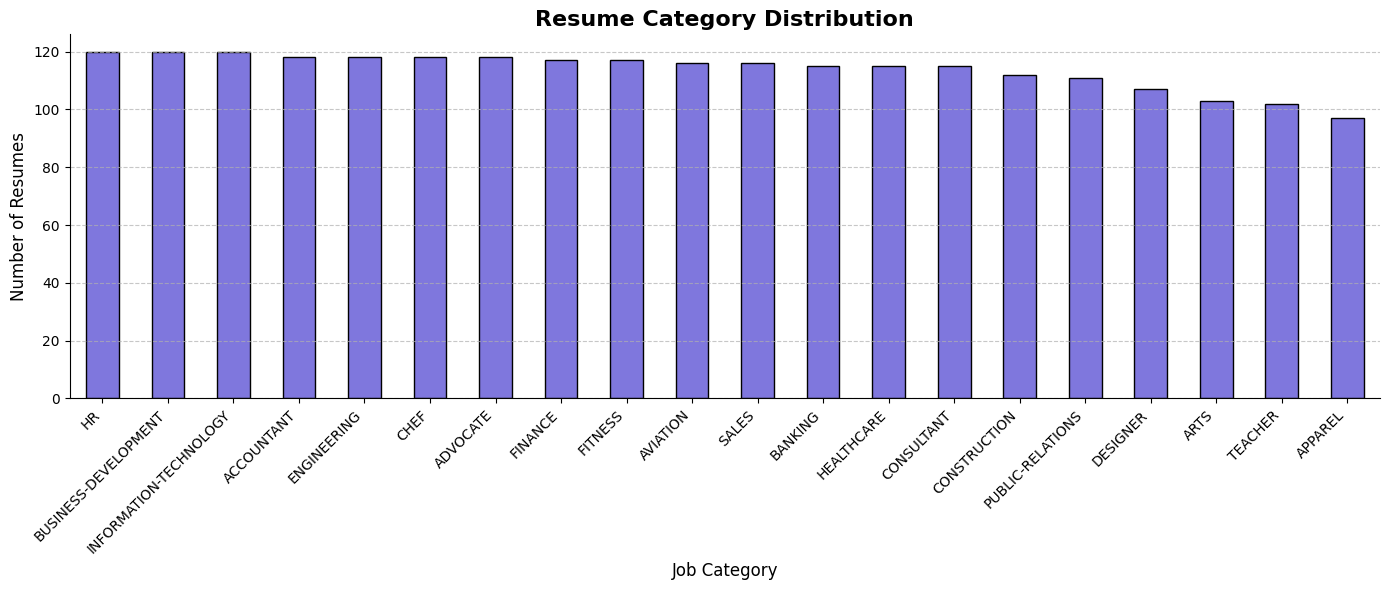

In [148]:
# Fixed Visual: Better alignment and layout
plt.figure(figsize=(14, 6))
category_counts.head(20).plot(kind='bar', color=PALETTE[4], edgecolor='black')

plt.title('Resume Category Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Job Category', fontsize=12)
plt.ylabel('Number of Resumes', fontsize=12)

# This part fixes the alignment
plt.xticks(rotation=45, ha='right', fontsize=10) 

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # This ensures names don't get cut off
plt.show()


